**Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,roc_auc_score,confusion_matrix,roc_curve
import seaborn as sns
from xgboost import XGBClassifier
from xgboost import XGBClassifier

**LOAD DATASET**

In [ ]:
df=pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df)

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL             No  ...   
1        

**2.Data Preprocessing**

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.drop_duplicates()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


**3. Exploratory Data Analysis (EDA)**

In [ ]:
df["Churn"]=df["Churn"].map({"No": 0,"Yes":1})

In [ ]:
X=df[['tenure', 'MonthlyCharges']]
y=df["Churn"]

In [ ]:
pd.get_dummies(X)

,tenure,MonthlyCharges
0,1,29.85
1,34,56.95
2,2,53.85
3,45,42.30
4,2,70.70
...,...,...
7038,24,84.80
7039,72,103.20
7040,11,29.60
7041,4,74.40


**"COUNT PLOT CHART"**

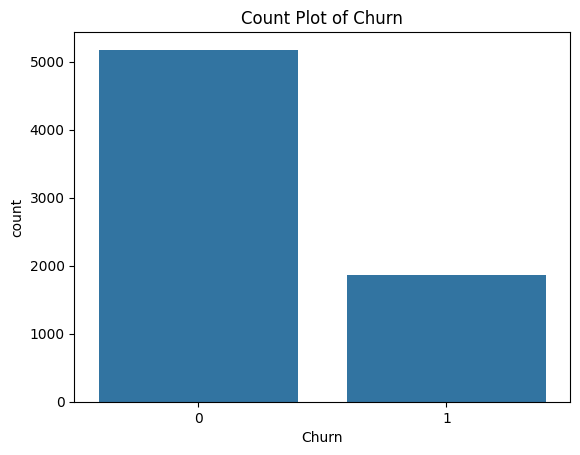

In [ ]:
sns.countplot(x="Churn", data=df)
plt.title("Count Plot of Churn")
plt.show()

**"BAR CHART"**

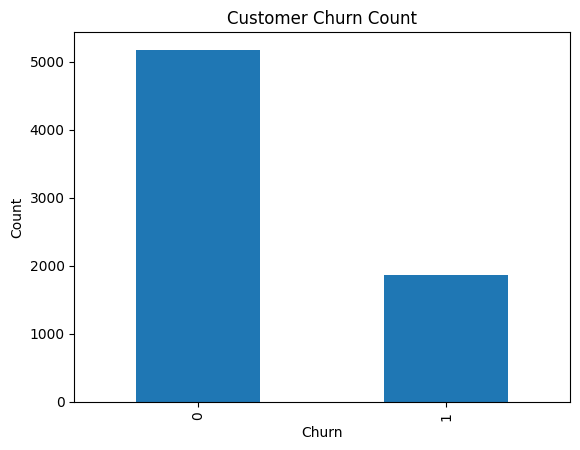

In [ ]:
df["Churn"].value_counts().plot(kind='bar')
plt.title("Customer Churn Count")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

**"HISTOGRAM CHART"**

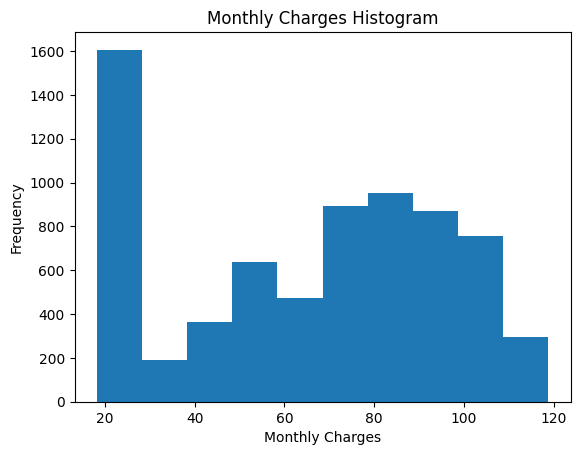

In [ ]:
plt.hist(df["MonthlyCharges"])

plt.title("Monthly Charges Histogram")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")
plt.show()

**"BOX PLOT CHAR"**

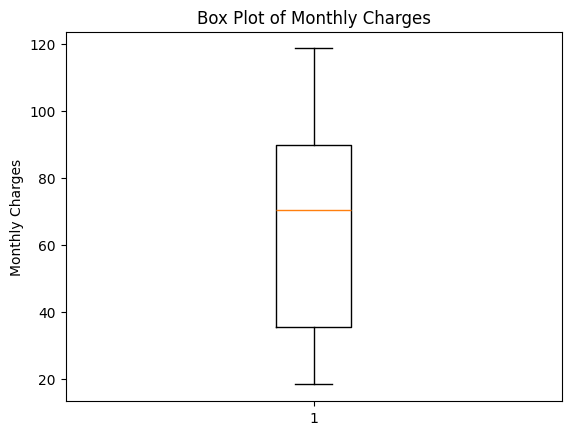

In [ ]:
plt.boxplot(df["MonthlyCharges"])
plt.title("Box Plot of Monthly Charges")
plt.ylabel("Monthly Charges")
plt.show()

**"PIE CHART"**

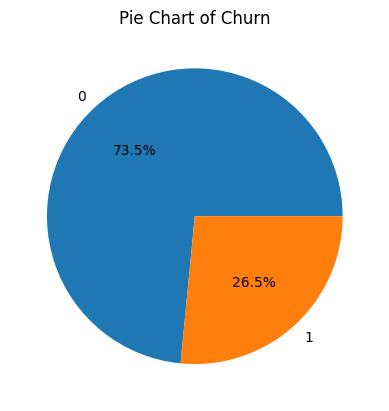

In [ ]:
churn_counts = df["Churn"].value_counts()
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%')
plt.title("Pie Chart of Churn")
plt.show()

**"CORRELATIO MATRIC CHART"***

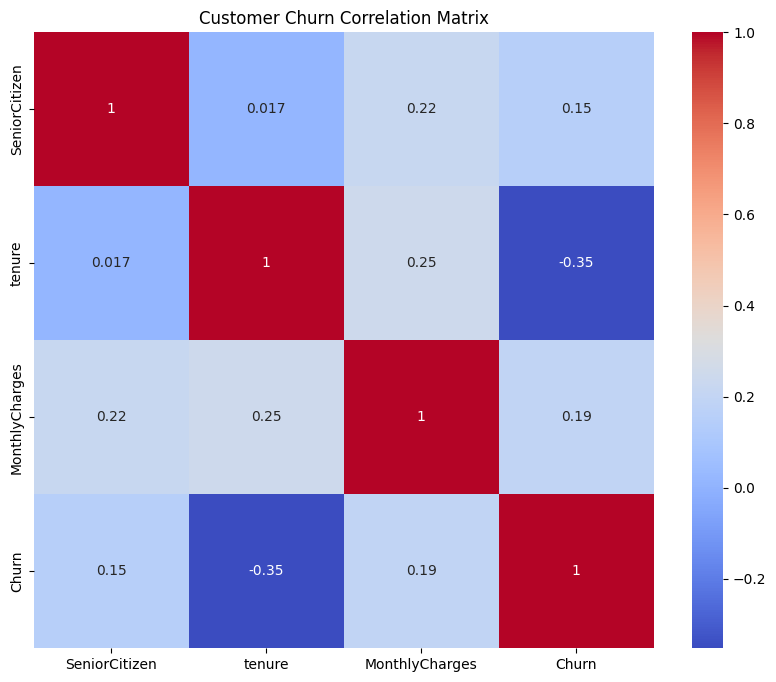

In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Customer Churn Correlation Matrix")
plt.show()

**"FAETURE DISTRIBUTION CHART"**

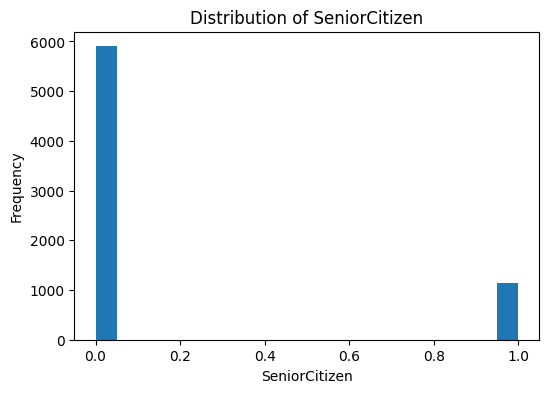

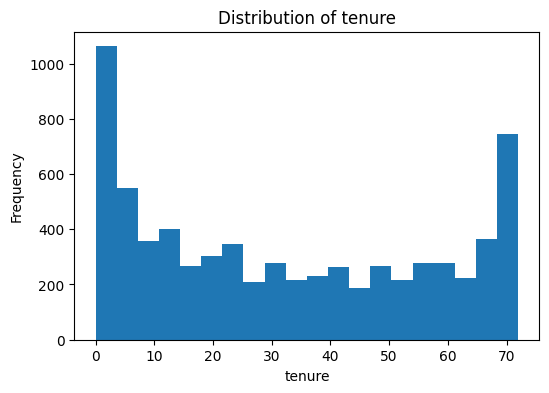

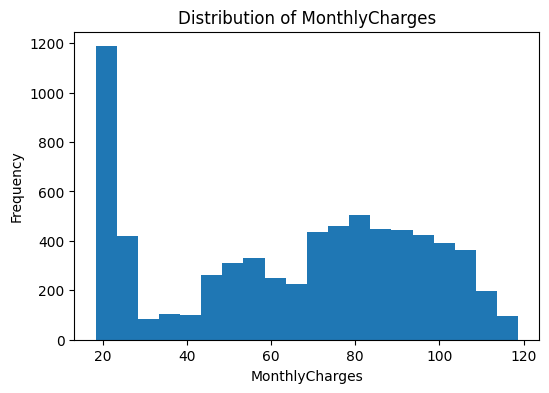

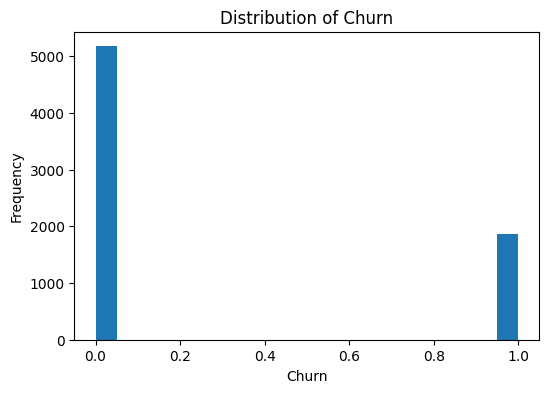

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=20)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()

***TRAIN_TEST_SPLIT***

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.2,random_state=42)

**Apply Model LogisticRegression**

In [ ]:
log_model=LogisticRegression()
log_model.fit(X_train,y_train)


LogisticRegression()

**Model Prediction**

In [ ]:
log_pred=log_model.predict(X_test)
log_prob=log_model.predict_proba(X_test)[:,1]

**Model Evaluation**

In [ ]:
print("Accuracy_Score:",accuracy_score(y_test,log_pred))
print("Precision_Score:",precision_score(y_test,log_pred))
print("Recall_Score:",recall_score(y_test,log_pred))
print("F1_Score:",f1_score(y_test,log_pred))
print("Confusion_Matric:",confusion_matrix(y_test,log_pred))
print("ROC_OUC_Score:",roc_auc_score(y_test,log_pred))
print("ROC_Curve:",roc_curve(y_test,log_pred))
print("Classification_Report:",classification_report(y_test,log_pred))


Accuracy_Score: 0.7977288857345636
Precision_Score: 0.6617647058823529
Recall_Score: 0.48257372654155495
F1_Score: 0.5581395348837209
Confusion_Matric: [[944  92]
 [193 180]]
ROC_OUC_Score: 0.696885318869233
ROC_Curve: (array([0.        , 0.08880309, 1.        ]), array([0.        , 0.48257373, 1.        ]), array([inf,  1.,  0.]))
Classification_Report:               precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.48      0.56       373

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.71      1409
weighted avg       0.79      0.80      0.79      1409



**Apply Second Model DecisionTreeClassifier**

In [ ]:
dt_model=DecisionTreeClassifier()
dt_model.fit(X_train,y_train)

DecisionTreeClassifier()

**Model Prediction**

In [ ]:
dt_pred=dt_model.predict(X_test)
dt_prob=dt_model.predict_proba(X_test)[:,1]

**Model Evaluation**

In [ ]:
print("Accuracy_Score:",accuracy_score(y_test,dt_pred))
print("Precision_Score:",precision_score(y_test,dt_pred))
print("Recall_Score:",recall_score(y_test,dt_pred))
print("F1_Score:",f1_score(y_test,dt_pred))
print("Confusion_Matric:",confusion_matrix(y_test,dt_pred))
print("ROC_OUC_Score:",roc_auc_score(y_test,dt_pred))
print("ROC_Curve:",roc_curve(y_test,dt_pred))
print("Classification_Report:",classification_report(y_test,dt_pred))

Accuracy_Score: 0.723207948899929
Precision_Score: 0.4768392370572207
Recall_Score: 0.4691689008042895
F1_Score: 0.47297297297297297
Confusion_Matric: [[844 192]
 [198 175]]
ROC_OUC_Score: 0.6419203577380521
ROC_Curve: (array([0.        , 0.18532819, 1.        ]), array([0.       , 0.4691689, 1.       ]), array([inf,  1.,  0.]))
Classification_Report:               precision    recall  f1-score   support

           0       0.81      0.81      0.81      1036
           1       0.48      0.47      0.47       373

    accuracy                           0.72      1409
   macro avg       0.64      0.64      0.64      1409
weighted avg       0.72      0.72      0.72      1409



**PRE PRUNING**

In [ ]:
model_pre = DecisionTreeClassifier(max_depth=4)
model_pre.fit(X_train,y_train)

y_pred_pre = model_pre.predict(X_test)
print("pre_pruning Accuracy:",accuracy_score(y_test,y_pred_pre))




pre_pruning Accuracy: 0.7913413768630234


**POST PRUNING**

In [ ]:
model_post=DecisionTreeClassifier(ccp_alpha=0.01)
model_post.fit(X_train,y_train)

model_post_pred=model_post.predict(X_test)
print("post_pruning Accuracy:",accuracy_score(y_test,model_post_pred))

post_pruning Accuracy: 0.7920511000709723


**Apply Third Model RandomForestClassifier**

In [ ]:
RFC_model=RandomForestClassifier(n_estimators=100,random_state=42)
RFC_model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

**Model Prediction**

In [ ]:
RFC_model_pred=RFC_model.predict(X_test)
RFC_model_prob=RFC_model.predict_proba(X_test)[:,1]

**Model Evaluation**

In [ ]:
print("Accuracy_Score:",accuracy_score(y_test,RFC_model_pred))
print("Precision_Score:",precision_score(y_test,RFC_model_pred))
print("Recall_Score:",recall_score(y_test,RFC_model_pred))
print("F1_Score:",f1_score(y_test,RFC_model_pred))
print("Confusion_Matric:",confusion_matrix(y_test,RFC_model_pred))
print("ROC_OUC_Score:",roc_auc_score(y_test,RFC_model_pred))
print("ROC_Curve:",roc_curve(y_test,RFC_model_pred))
print("Classification_Report:",classification_report(y_test,RFC_model_pred))

Accuracy_Score: 0.7544357700496807
Precision_Score: 0.5415384615384615
Recall_Score: 0.4718498659517426
F1_Score: 0.504297994269341
Confusion_Matric: [[887 149]
 [197 176]]
ROC_OUC_Score: 0.6640137360646744
ROC_Curve: (array([0.        , 0.14382239, 1.        ]), array([0.        , 0.47184987, 1.        ]), array([inf,  1.,  0.]))
Classification_Report:               precision    recall  f1-score   support

           0       0.82      0.86      0.84      1036
           1       0.54      0.47      0.50       373

    accuracy                           0.75      1409
   macro avg       0.68      0.66      0.67      1409
weighted avg       0.75      0.75      0.75      1409



**CONCLUSION**

***LogisticRegression***:
**Accuracy_Score**: 0.7977288857345636
**Precision_Score:** 0.6617647058823529
**Recall_Score:** 0.48257372654155495
**F1_Score**: 0.5581395348837209
**Confusion_Matric**: **[TP:944  FP:92
                  FN:193 TN180]**
                  ROC_OUC_Score: 0.696885318869233


***DecisionTreeClassifier*** : Accuracy_Score: 0.7210787792760823
**Precision_Score**: 0.47282608695652173
**Recall_Score**: 0.46648793565683644
**F1_Score**: 0.46963562753036436
**Confusion_Matric:** **[TP: 842 FP:194
 FN:199 TN:174]**
**ROC_OUC_Score:** 0.6396146241990747

***RandomForestClassifier:***
**Accuracy_Score**: 0.7544357700496807
**Precision_Score:** 0.5415384615384615
**Recall_Score:** 0.4718498659517426
**F1_Score:** 0.504297994269341
**Confusion_Matric:** **[TP:887 FP:149
 FN:197 TN:176]**
**ROC_OUC_Score:** 0.6640137360646744

**In conclusion, Logistic Regression performed the best among all models, showing the highest and most balanced accuracy, precision, recall, and F1-score.**

Apply Fourth model **XGBOOST**

In [ ]:
xg_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42)
xg_model.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xg_model_pred=xg_model.predict(X_test)
xg_model_prob=xg_model.predict_proba(X_test)[:,1]

In [ ]:
print("Accuracy_Score:",accuracy_score(y_test,xg_model_pred))
print("Precision_Score:",precision_score(y_test,xg_model_pred))
print("Recall_Score:",recall_score(y_test,xg_model_pred))
print("F1_Score:",f1_score(y_test,RFC_model_pred))
print("Confusion_Matric:",confusion_matrix(y_test,xg_model_pred))
print("ROC_OUC_Score:",roc_auc_score(y_test,xg_model_pred))
print("ROC_Curve:",roc_curve(y_test,xg_model_pred))
print("Classification_Report:",classification_report(y_test,xg_model_pred))

Accuracy_Score: 0.8062455642299503
Precision_Score: 0.6908396946564885
Recall_Score: 0.48525469168900803
F1_Score: 0.504297994269341
Confusion_Matric: [[955  81]
 [192 181]]
ROC_OUC_Score: 0.70353468175184
ROC_Curve: (array([0.        , 0.07818533, 1.        ]), array([0.        , 0.48525469, 1.        ]), array([inf,  1.,  0.]))
Classification_Report:               precision    recall  f1-score   support

           0       0.83      0.92      0.87      1036
           1       0.69      0.49      0.57       373

    accuracy                           0.81      1409
   macro avg       0.76      0.70      0.72      1409
weighted avg       0.80      0.81      0.79      1409

